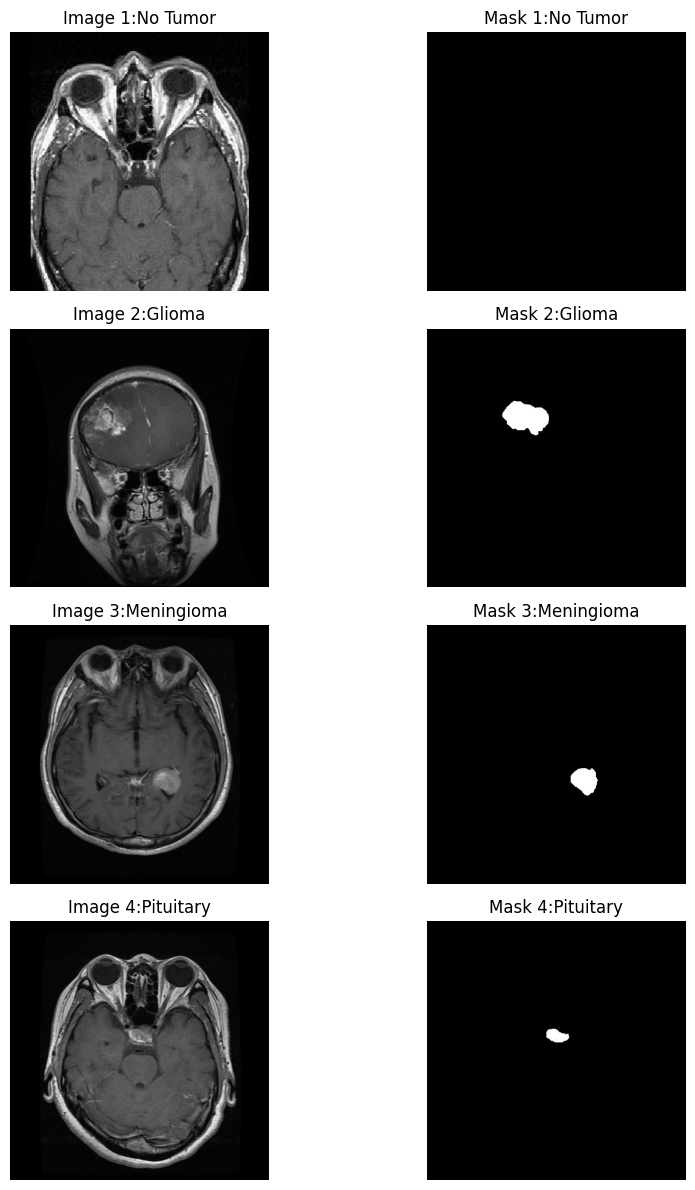

In [10]:
import cv2
import matplotlib.pyplot as plt


fig, axs = plt.subplots(4, 2, figsize=(10, 12))  # Adjusting the size for better visibility


img1 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/image/0/Tr-noTr_0000.jpg")
img2 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/mask/0/Tr-noTr_0000_m.jpg")
img3 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/image/1/Tr-glTr_0000.jpg")
img4 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/mask/1/Tr-glTr_0000_m.jpg")
img5 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/image/2/Tr-meTr_0001.jpg")
img6 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/mask/2/Tr-meTr_0001_m.jpg")
img7 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/image/3/Tr-piTr_0000.jpg")
img8 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/mask/3/Tr-piTr_0000_m.jpg")



# Plot the images
axs[0, 0].imshow(img1)
axs[0, 0].set_title("Image 1:No Tumor")
axs[0, 0].axis('off')

axs[0, 1].imshow(img2)
axs[0, 1].set_title("Mask 1:No Tumor")
axs[0, 1].axis('off')

axs[1, 0].imshow(img3)
axs[1, 0].set_title("Image 2:Glioma")
axs[1, 0].axis('off')

axs[1, 1].imshow(img4)
axs[1, 1].set_title("Mask 2:Glioma")
axs[1, 1].axis('off')

axs[2, 0].imshow(img5)
axs[2, 0].set_title("Image 3:Meningioma")
axs[2, 0].axis('off')

axs[2, 1].imshow(img6)
axs[2, 1].set_title("Mask 3:Meningioma")
axs[2, 1].axis('off')

axs[3, 0].imshow(img7)
axs[3, 0].set_title("Image 4:Pituitary")
axs[3, 0].axis('off')

axs[3, 1].imshow(img8)
axs[3, 1].set_title("Mask 4:Pituitary")
axs[3, 1].axis('off')

plt.tight_layout()  
plt.show()


In [ ]:
import os
import numpy as np
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from albumentations import HorizontalFlip, VerticalFlip, Rotate, Compose

DATASET_PATH = r"/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset"
CLASSES = ['no_tumor', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']
TARGET_SIZE = (128, 128)

# Augmentation function
def augment_data(image, mask):
    transform = Compose([
        HorizontalFlip(p=0.5),
        VerticalFlip(p=0.5),
        Rotate(limit=45, p=0.5)
    ])
    augmented = transform(image=image, mask=mask)
    return augmented["image"], augmented["mask"]

# Load dataset and balance classes
def load_balanced_data(data_path, classes, target_size):
    images = []
    masks = []
    labels = []
    class_counts = [0] * len(classes)
    
    for class_index, class_name in enumerate(classes):
        image_folder = os.path.join(data_path, 'image', str(class_index))
        mask_folder = os.path.join(data_path, 'mask', str(class_index))
        
        if not os.path.exists(image_folder) or not os.path.exists(mask_folder):
            continue

        for image_name in tqdm(os.listdir(image_folder), desc=f"Loading {class_name}"):
            if image_name.endswith(('.jpg', '.png')):
                image_path = os.path.join(image_folder, image_name)
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                if image is None:
                    continue
                
                image = cv2.resize(image, target_size)
                image = image / 255.0  

                mask_name = image_name.replace('.jpg', '_m.jpg').replace('.png', '_m.png')
                mask_path = os.path.join(mask_folder, mask_name)

                if os.path.exists(mask_path):
                    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    if mask is None:
                        continue

                    mask = cv2.resize(mask, target_size)
                    mask = mask / 255.0  

                    images.append(image)
                    masks.append(mask)
                    labels.append(class_index)
                    class_counts[class_index] += 1
    
    max_count = max(class_counts)
    
    for i in range(len(images)):
        while class_counts[labels[i]] < max_count:
            aug_image, aug_mask = augment_data(images[i], masks[i])
            images.append(aug_image)
            masks.append(aug_mask)
            labels.append(labels[i])
            class_counts[labels[i]] += 1
    
    images = np.array(images, dtype=np.float32).reshape(-1, 128, 128, 1)
    masks = np.array(masks, dtype=np.float32).reshape(-1, 128, 128, 1)
    labels = np.array(labels, dtype=np.int32)
    
    return images, masks, labels

# Data Splitting
def split_data(images, masks, labels, test_size=0.2, val_size=0.1):
    Img_train, Img_test, label_train, label_test, mask_train, mask_test = train_test_split(
        images, labels, masks, test_size=test_size, random_state=42, stratify=labels
    )

    Img_train, Img_val, label_train, label_val, mask_train, mask_val = train_test_split(
        Img_train, label_train, mask_train, test_size=val_size, random_state=42, stratify=label_train
    )
    
    return Img_train, Img_val, Img_test, label_train, label_val, label_test, mask_train, mask_val, mask_test


if __name__ == "__main__":
    images, masks, labels = load_balanced_data(DATASET_PATH, CLASSES, TARGET_SIZE)
    print(f"Total Images: {images.shape[0]}, Total Masks: {masks.shape[0]}, Total Labels: {labels.shape[0]}")

    Img_train, Img_val, Img_test, label_train, label_val, label_test, mask_train, mask_val, mask_test = split_data(
        images, masks, labels, test_size=0.2, val_size=0.1
    )

    print(f"Training data: {Img_train.shape[0]}")
    print(f"Validation data: {Img_val.shape[0]}")
    print(f"Test data: {Img_test.shape[0]}")


Loading pituitary_tumor: 100%|██████████| 994/994 [00:05<00:00, 177.00it/s]


Total Images: 6380, Total Masks: 6380, Total Labels: 6380
Training data: 4593
Validation data: 511
Test data: 1276


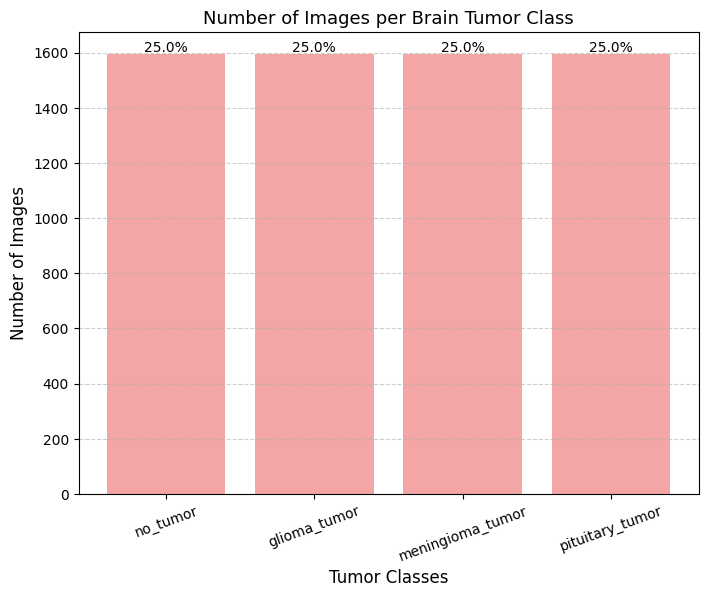

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


unique, counts = np.unique(labels, return_counts=True)
class_counts = dict(zip(CLASSES, counts))


total_images = sum(class_counts.values())
percentages = [(count / total_images) * 100 for count in class_counts.values()]


plt.figure(figsize=(8, 6))
bars = plt.bar(class_counts.keys(), class_counts.values(), color='lightcoral', alpha=0.7)


for bar, percentage in zip(bars, percentages):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{percentage:.1f}%', ha='center', fontsize=10)


plt.xlabel('Tumor Classes', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Number of Images per Brain Tumor Class', fontsize=13)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.show()


In [13]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Conv2DTranspose, 
                                     concatenate, BatchNormalization, Dropout)
from tensorflow.keras.regularizers import l2

def unet_model(input_size=(128, 128, 1)):
    inputs = Input(input_size)
    reg = l2(0.0001)  

    # Encoder (Down Sampling)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c1)
    c1 = BatchNormalization()(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    p1 = Dropout(0.3)(p1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(p1)
    c2 = BatchNormalization()(c2)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c2)
    c2 = BatchNormalization()(c2)
    p2 = MaxPooling2D((2, 2))(c2)
    p2 = Dropout(0.3)(p2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(p2)
    c3 = BatchNormalization()(c3)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c3)
    c3 = BatchNormalization()(c3)
    p3 = MaxPooling2D((2, 2))(c3)
    p3 = Dropout(0.4)(p3)

    # Bottleneck
    c5 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(p3)
    c5 = BatchNormalization()(c5)
    c5 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c5)
    c5 = BatchNormalization()(c5)
    c5 = Dropout(0.5)(c5)

    # Decoder (Up Sampling)
    u6 = Conv2DTranspose(256, (2, 2), strides=(2,2), padding='same')(c5)
    u6 = concatenate([u6, c3])
    c6 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(u6)
    c6 = BatchNormalization()(c6)
    c6 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c6)
    c6 = BatchNormalization()(c6)

    u7 = Conv2DTranspose(128, (2, 2), strides=(2,2), padding='same')(c6)
    u7 = concatenate([u7, c2])
    c7 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(u7)
    c7 = BatchNormalization()(c7)
    c7 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c7)
    c7 = BatchNormalization()(c7)

    u8 = Conv2DTranspose(64, (2, 2), strides=(2,2), padding='same')(c7)
    u8 = concatenate([u8, c1])
    c8 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(u8)
    c8 = BatchNormalization()(c8)
    c8 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c8)
    c8 = BatchNormalization()(c8)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c8)

    model = Model(inputs, outputs)
    return model

In [14]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

def dice_coef(mask_true, mask_pred, smooth=1e-6):
    mask_true_f = tf.keras.backend.flatten(mask_true)
    mask_pred_f = tf.keras.backend.flatten(mask_pred)
    intersection = tf.keras.backend.sum(mask_true_f * mask_pred_f)
    
    return (2. * intersection + smooth) / (tf.keras.backend.sum(mask_true_f) + tf.keras.backend.sum(mask_pred_f) + smooth)

def dice_loss(mask_true, mask_pred):
    return 1 - dice_coef(mask_true, mask_pred)

def iou_coef(mask_true, mask_pred, smooth=1e-6):
    mask_true_f = tf.keras.backend.flatten(mask_true)
    mask_pred_f = tf.keras.backend.flatten(mask_pred)
    intersection = tf.keras.backend.sum(mask_true_f * mask_pred_f)
    union = tf.keras.backend.sum(mask_true_f) + tf.keras.backend.sum(mask_pred_f) - intersection
    
    return (intersection + smooth) / (union + smooth)


model = unet_model()


model.compile(optimizer=Adam(learning_rate=0.0001), loss=dice_loss, metrics=["accuracy",dice_coef, iou_coef])


model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 128, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_15 (Conv2D)        │ (None, 128, 128, 64)   │            640 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_14    │ (None, 128, 128, 64)   │            256 │ conv2d_15[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_16 (Conv2D)        │ (None, 128, 128, 64)   │         36,928 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_15    │ (None, 128, 128, 64)   │            256 │ conv2d_16[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 64, 64, 64)     │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 64, 64, 64)     │              0 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_17 (Conv2D)        │ (None, 64, 64, 128)    │         73,856 │ dropout_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_16    │ (None, 64, 64, 128)    │            512 │ conv2d_17[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_18 (Conv2D)        │ (None, 64, 64, 128)    │        147,584 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_17    │ (None, 64, 64, 128)    │            512 │ conv2d_18[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 32, 32, 128)    │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_5 (Dropout)       │ (None, 32, 32, 128)    │              0 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_19 (Conv2D)        │ (None, 32, 32, 256)    │        295,168 │ dropout_5[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_18    │ (None, 32, 32, 256)    │          1,024 │ conv2d_19[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_20 (Conv2D)   

 Total params: 7,707,457 (29.40 MB)

 Trainable params: 7,701,825 (29.38 MB)

 Non-trainable params: 5,632 (22.00 KB)

In [ ]:

import pickle


from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    mode='min'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  
    patience=3,  
    min_lr=1e-6  
)


history = model.fit(
    Img_train, mask_train,
    validation_data=(Img_val, mask_val),
    epochs=50,
    batch_size=16,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]  
)



with open('history1.pkl', 'wb') as f:
    pickle.dump(history.history, f)

model.save("best_model.h5")
print("Model and History Saved 100%")





Epoch 1/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 52s 123ms/step - accuracy: 0.7515 - dice_coef: 0.0971 - iou_coef: 0.0516 - loss: 1.1126 - val_accuracy: 0.2156 - val_dice_coef: 0.0352 - val_iou_coef: 0.0179 - val_loss: 1.1098 - learning_rate: 1.0000e-04
Epoch 2/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 26s 89ms/step - accuracy: 0.9355 - dice_coef: 0.2287 - iou_coef: 0.1307 - loss: 0.9100 - val_accuracy: 0.9131 - val_dice_coef: 0.2338 - val_iou_coef: 0.1330 - val_loss: 0.8922 - learning_rate: 1.0000e-04
Epoch 3/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 26s 89ms/step - accuracy: 0.9737 - dice_coef: 0.3989 - iou_coef: 0.2544 - loss: 0.7249 - val_accuracy: 0.9507 - val_dice_coef: 0.3239 - val_iou_coef: 0.1952 - val_loss: 0.7953 - learning_rate: 1.0000e-04
Epoch 4/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 25s 88ms/step - accuracy: 0.9811 - dice_coef: 0.5417 - iou_coef: 0.3832 - loss: 0.5780 - val_accuracy: 0.9854 - val_dice_coef: 0.6968 - val_iou_coef: 0.5467 - val_loss: 0.4212 - learning_rate: 1.0000e-04
Epoch 5/50
288/288 ━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 753ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


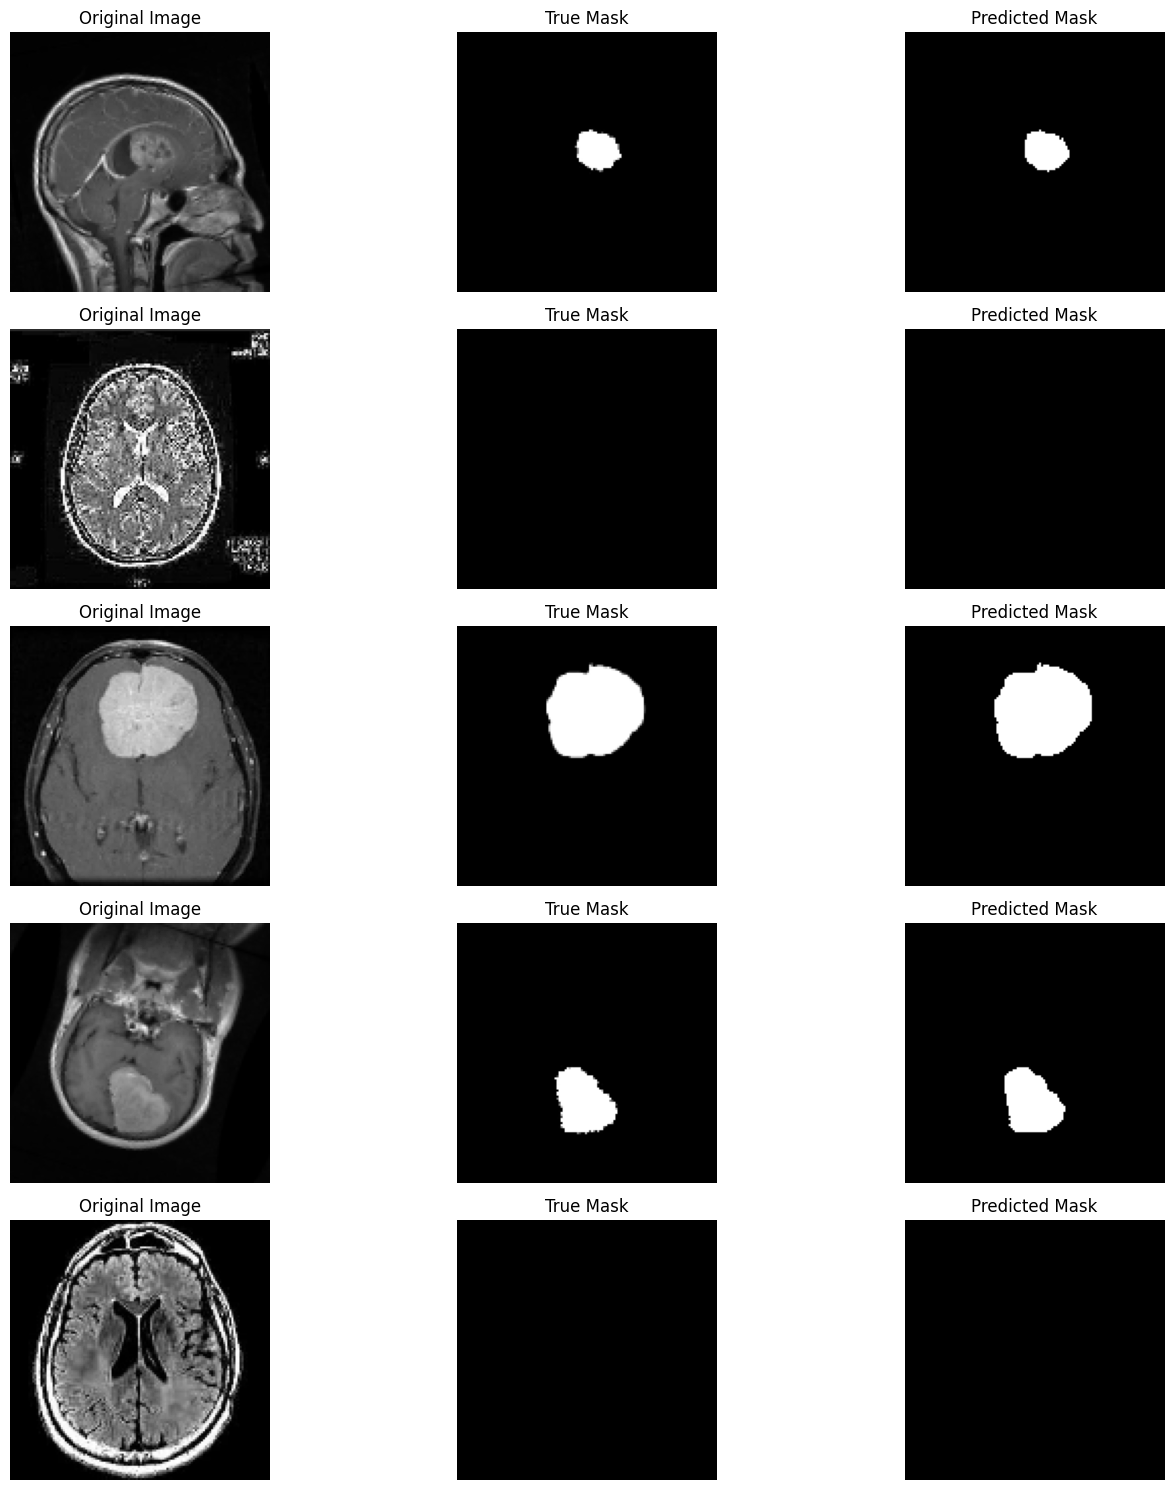

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def test_model(model, Img_test, mask_test, num_samples=5):
  
    indices = np.random.choice(len(Img_test), num_samples, replace=False)  

    plt.figure(figsize=(15, num_samples * 3))

    for i, idx in enumerate(indices):
        test_image = Img_test[idx]
        true_mask = mask_test[idx]

        
        test_image_input = np.expand_dims(test_image, axis=0)

        
        pred_mask = model.predict(test_image_input)[0]  

        
        pred_mask = (pred_mask > 0.5).astype(np.uint8)

        
        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(test_image, cmap='gray')
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(true_mask, cmap='gray')
        plt.title("True Mask")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(pred_mask, cmap='gray')
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()



test_model(model, Img_test, mask_test, num_samples=5)


In [17]:

test_loss,test_acc,test_dice,test_iou = model.evaluate(Img_test, mask_test, batch_size=16)


print(f"Test Loss (Dice Loss) : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Dice Coefficient: {test_dice:.4f}")
print(f"Test IoU Coefficient: {test_iou:.4f}")



80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9938 - dice_coef: 0.9479 - iou_coef: 0.9021 - loss: 0.1233
Test Loss (Dice Loss) : 0.1296
Test Accuracy : 0.9936
Test Dice Coefficient: 0.9414
Test IoU Coefficient: 0.8912


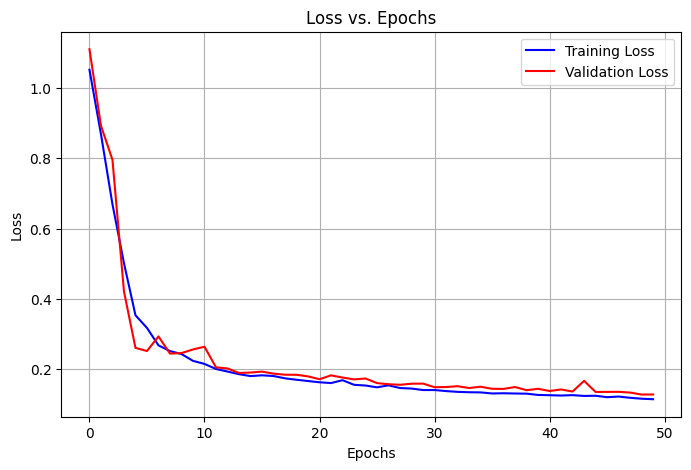

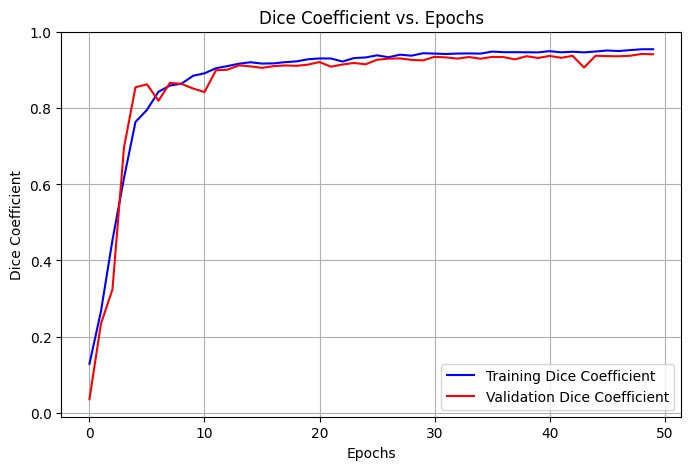

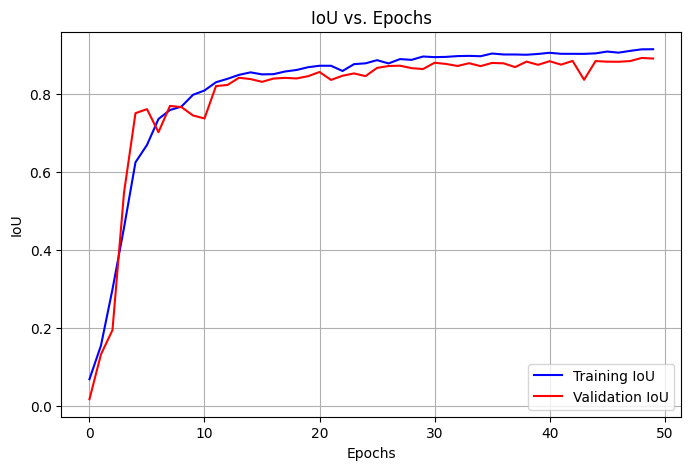

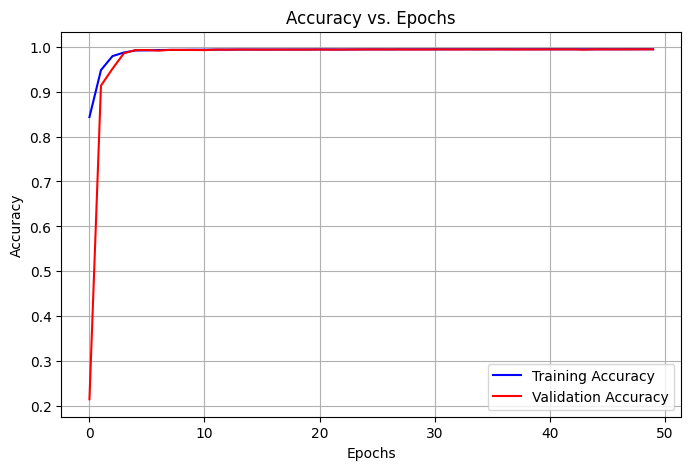

In [18]:
import matplotlib.pyplot as plt

# --- Loss Curve (Dice Loss) ---
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs. Epochs')
plt.legend()
plt.grid()
plt.show()


# --- Dice Coefficient Curve ---
train_dice = history.history['dice_coef']
val_dice = history.history['val_dice_coef']

plt.figure(figsize=(8, 5))
plt.plot(train_dice, label='Training Dice Coefficient', color='blue')
plt.plot(val_dice, label='Validation Dice Coefficient', color='red')

plt.xlabel('Epochs')
plt.ylabel('Dice Coefficient')
plt.title('Dice Coefficient vs. Epochs')
plt.legend()
plt.grid()
plt.show()


# --- IoU Curve ---
train_iou = history.history['iou_coef']
val_iou = history.history['val_iou_coef']

plt.figure(figsize=(8, 5))
plt.plot(train_iou, label='Training IoU', color='blue')
plt.plot(val_iou, label='Validation IoU', color='red')

plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.title('IoU vs. Epochs')
plt.legend()
plt.grid()
plt.show()


# --- Accuracy Curve ---
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='red')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epochs')
plt.legend()
plt.grid()
plt.show()

